In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# K-Means Clustering

    K-Means Clustering is an unsupervised learning algorithm designed to partition a dataset into K distinct, non-overlapping clusters. Applicable in customer segmentation, image compression (color quantization), document categorization, anomaly detection.

- **Steps**
  1) Decide n (K) clusters (No. of cluster to make)
  2) Init centroids
  3) Assign cluster
  4) Move centroids
  5) Loop step 3 & 4 untill movement in centroids become zero

- **How to Decide No. of Clusters to initialize**

      Use the elbow method (plot WCSS vs. KK) or domain knowledge.

# Dataset

In [3]:
X,y = make_blobs(n_samples=200,n_features=2,centers=3,center_box=(-20,10,20))

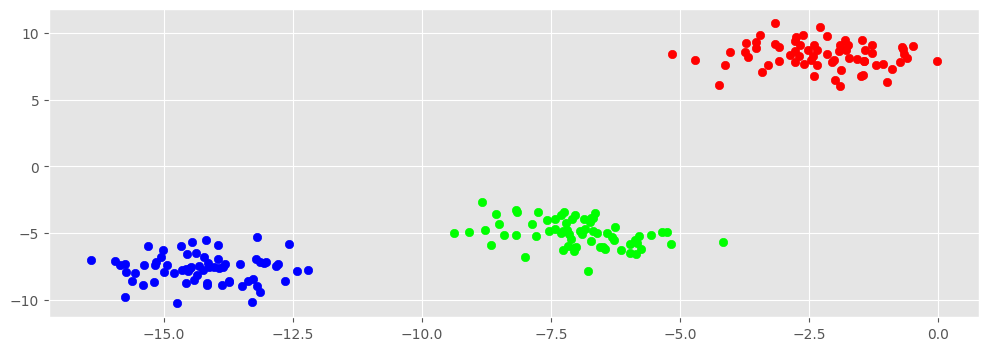

In [4]:
plt.figure(figsize=(12,4))
plt.scatter(X[:,0][y==0],X[:,1][y==0], color=(1,0,0,1))
plt.scatter(X[:,0][y==1],X[:,1][y==1], color=(0,0,1,1))
plt.scatter(X[:,0][y==2],X[:,1][y==2], color=(0,1,0,1))
plt.scatter(X[:,0][y==3],X[:,1][y==3], color=(1,1,0,1))
plt.show()

# My KMrans Model

In [5]:
class My_KMeans:
    def __init__(self,K=2,itration=200):
        self.K = K
        self.itration = itration
        self.centroids = None
        self.clusters = None
        self.inertia_ = None
        
    def fit_predict(self,X):
        # Init Centroids
        rand_index = np.random.randint(0,X.shape[0],size=self.K)
        self.centroids = X[rand_index]
        inertia = []

        for _ in range(self.itration):
            # Assign Clusters
            self.clusters = self.Assign_Cluster(X)
            # Move Centroids
            old_centroids = self.centroids
            self.centroids = self.Move_Centroids(X)
            if (old_centroids == self.centroids).all():
                break
        # print(self.centroids)
        for i in range(self.centroids.shape[0]):
            inertia.append(np.sum(np.square(X[self.clusters==i]-self.centroids[i])))
        self.inertia_ = np.sum(inertia)
        return self.clusters

    def Assign_Cluster(self, X):
        clusters = []
        for row in range(X.shape[0]):
            # if row in self.centroids:
            #     continue
            distance = np.sqrt(np.sum((X[row] - self.centroids)**2, axis=1))
            distance_min = distance.min()
            clusters.append(np.where(distance==distance_min)[0][0])
        return np.array(clusters)

    def Move_Centroids(self, X):
        centroids = []
        for i in range(self.centroids.shape[0]):
            centroids.append(X[self.clusters==i].mean(axis=0))
        return np.array(centroids)

In [6]:
kmean = My_KMeans(K=3, itration=10000)
pred = kmean.fit_predict(X)

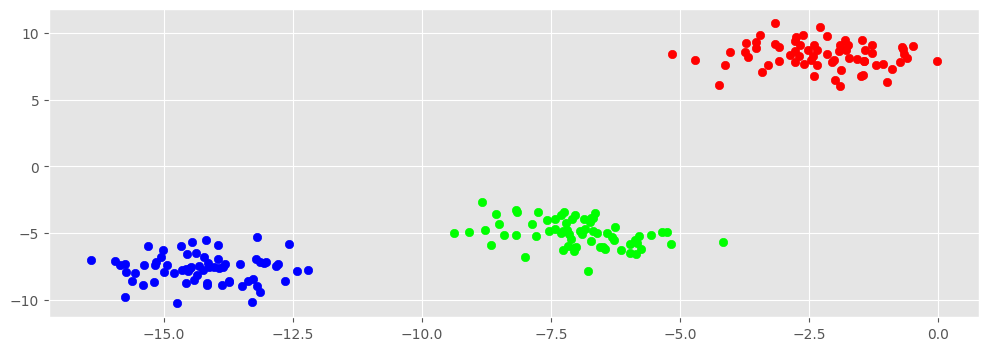

In [7]:
plt.figure(figsize=(12,4))
plt.scatter(X[:,0][pred==0],X[:,1][pred==0], color=(1,0,0,1))
plt.scatter(X[:,0][pred==1],X[:,1][pred==1], color=(0,0,1,1))
plt.scatter(X[:,0][pred==2],X[:,1][pred==2], color=(0,1,0,1))
plt.scatter(X[:,0][pred==3],X[:,1][pred==3], color=(1,1,0,1))
plt.show()

In [8]:
kmean.centroids

array([[ -2.28582374,   8.33776364],
       [-14.25307776,  -7.65965905],
       [ -7.00846371,  -5.00576686]])

In [9]:
kmean.inertia_

np.float64(412.8687148804716)

In [11]:
Elbow_Points:dict = {}
for i in range(1,11):
    kmean = My_KMeans(K=i, itration=10000)
    kmean.fit_predict(X)
    Elbow_Points[i] = kmean.inertia_

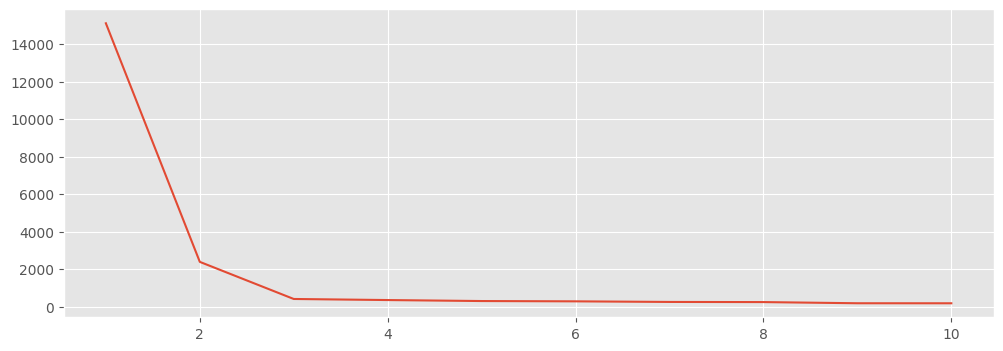

In [12]:
plt.figure(figsize=(12,4))
sns.lineplot(x=Elbow_Points.keys(), y=Elbow_Points.values())
plt.show()

# SkLearn Model

In [13]:
SK_KMeans = KMeans(n_clusters=3)
pred = SK_KMeans.fit_predict(X)

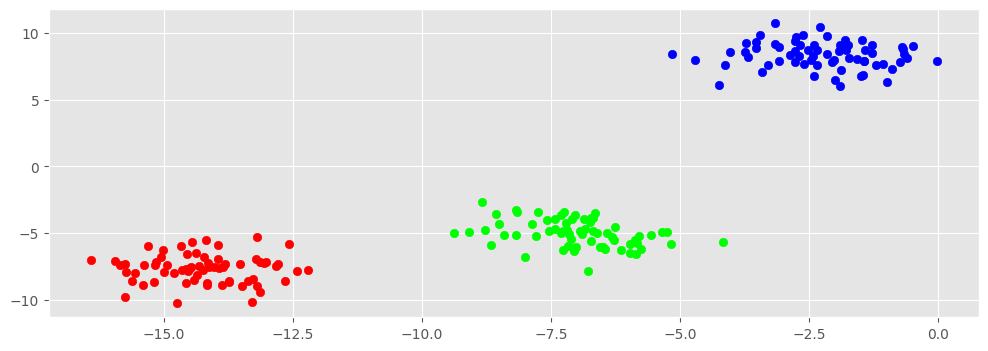

In [14]:
plt.figure(figsize=(12,4))
plt.scatter(X[:,0][pred==0],X[:,1][pred==0], color=(1,0,0,1))
plt.scatter(X[:,0][pred==1],X[:,1][pred==1], color=(0,0,1,1))
plt.scatter(X[:,0][pred==2],X[:,1][pred==2], color=(0,1,0,1))
plt.scatter(X[:,0][pred==3],X[:,1][pred==3], color=(1,1,0,1))
plt.show()

In [15]:
SK_KMeans.cluster_centers_

array([[-14.25307776,  -7.65965905],
       [ -2.28582374,   8.33776364],
       [ -7.00846371,  -5.00576686]])

In [16]:
SK_KMeans.inertia_

412.86871488047154

In [17]:
Elbow_Points:dict = {}
for i in range(1,11):
    SK_KMeans = KMeans(n_clusters=i)
    SK_KMeans.fit_predict(X)
    Elbow_Points[i] = SK_KMeans.inertia_

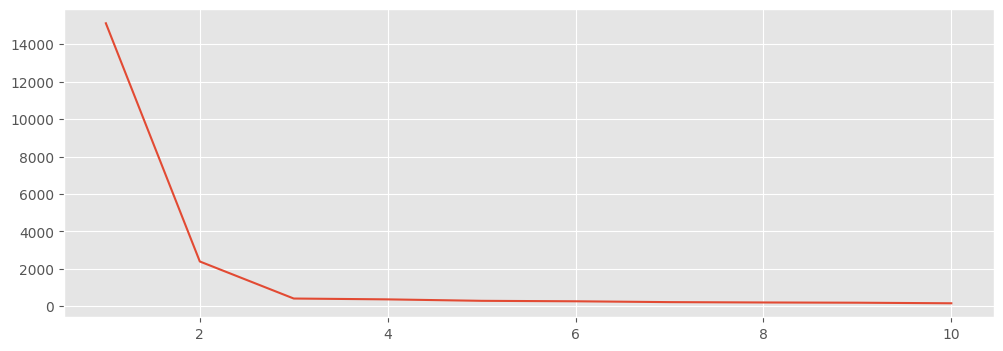

In [18]:
plt.figure(figsize=(12,4))
sns.lineplot(x=Elbow_Points.keys(), y=Elbow_Points.values())
plt.show()